<a href="https://colab.research.google.com/github/Kashishkewat/python_practice/blob/main/day32_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Python mini project:- Titanic survival prediction**


In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [66]:
from google.colab import files
uploaded=files.upload()

Saving titanic.csv to titanic (1).csv


In [67]:
data=pd.read_csv("titanic.csv")

In [96]:
data.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",0,34.5,0,0,330911,7.8292,NaN,1
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",1,47.0,1,0,363272,7.0000,NaN,2
2,894,0,2,"Myles, Mr. Thomas Francis",0,62.0,0,0,240276,9.6875,NaN,1
3,895,0,3,"Wirz, Mr. Albert",0,27.0,0,0,315154,8.6625,NaN,2
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",1,22.0,1,1,3101298,12.2875,NaN,2
5,897,0,3,"Svensson, Mr. Johan Cervin",0,14.0,0,0,7538,9.2250,NaN,2
6,898,1,3,"Connolly, Miss. Kate",1,30.0,0,0,330972,7.6292,NaN,1
7,899,0,2,"Caldwell, Mr. Albert Francis",0,26.0,1,1,248738,29.0000,NaN,2
8,900,1,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",1,18.0,0,0,2657,7.2292,NaN,0
9,901,0,3,"Davies, Mr. John Samuel",0,21.0,2,0,A/4 48871,24.1500,NaN,2


In [77]:
data.shape

(418, 12)

In [70]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [71]:
data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1


In [72]:
data['Age'] = data['Age'].fillna(data['Age'].mean())


In [73]:
data['Sex'] = data['Sex'].map({'male': 0,'female' : 1})


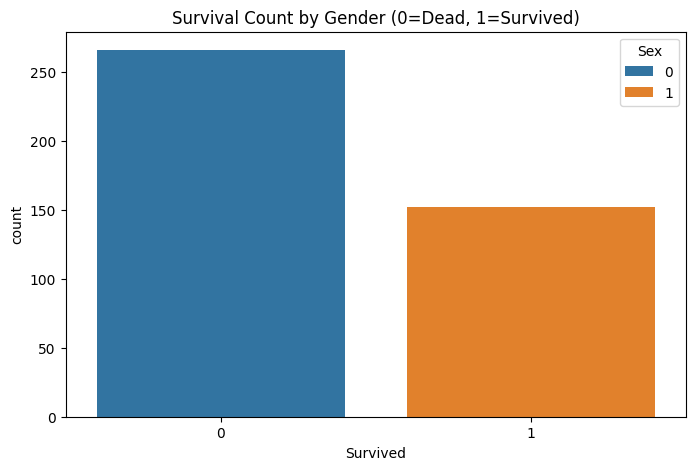

In [74]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Survived', hue='Sex', data=data)
plt.title('Survival Count by Gender (0=Dead, 1=Survived)')
plt.show()


In [75]:
data['Embarked'] = data['Embarked'].map({'C': 0, 'Q': 1, 'S': 2})


In [79]:
X = data[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex', 'Embarked']]
y = data['Survived']

In [80]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [81]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [82]:
# Before fitting, ensure no NaNs are present in X_train and X_test

# Impute missing 'Fare' values
# Calculate median of 'Fare' from training data to avoid data leakage
fare_median = X_train['Fare'].median()

# Fill NaNs in 'Fare' for both X_train and X_test using the median from X_train
X_train['Fare'] = X_train['Fare'].fillna(fare_median)
X_test['Fare'] = X_test['Fare'].fillna(fare_median)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [83]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [84]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 1.0

Confusion Matrix:
 [[50  0]
 [ 0 34]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        34

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



In [85]:
y_pred.sum()

np.int64(34)

In [86]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [87]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1 )

Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [106]:
# The model expects 7 features in the order: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex', 'Embarked']
# Assuming the original new_passenger values were intended for:
# Pclass = 3
# Sex = 1 (female)
# Age = 26
# SibSp = 0
# Parch = 0
# Fare = 7.25
# And assuming Embarked = 2 (for 'S' as per previous mapping)

new_passenger = [[3, 26, 0, 0, 7.25, 1, 2]] # Corrected order and added Embarked feature
print(model.predict(new_passenger))

[1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
